<a href="https://colab.research.google.com/github/isumakm/Weather-Prediction-and-Crop-Recommendation-System-/blob/Single-Crop-Analysis/Single_Crop_Analysis_%E2%80%93_Model_Training_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Single Crop Analysis – Model Training

 1: Load dataset

In [45]:
import pandas as pd

df = pd.read_csv("crop_suitability_training_data.csv")
print(df.shape)
print(df.head())


(2100, 17)
      crop  temperature_score  water_score  light_score  season_score  \
0  Brinjal           0.007099     0.259921     0.203325      0.080943   
1  Brinjal           0.852073     0.995028     0.990364      0.951273   
2  Brinjal           0.156681     0.110273     0.066356      0.194492   
3  Brinjal           0.213627     0.071758     0.215739      0.014188   
4  Brinjal           0.810279     0.875517     0.856482      0.993177   

   texture_score  awc_score  bulk_density_score  rooting_depth_score  \
0       0.196457   0.273732            0.110635             0.213200   
1       0.996061   0.753640            0.914380             0.875319   
2       0.326374   0.243897            0.270808             0.438098   
3       0.096949   0.335957            0.086775             0.221707   
4       0.874313   0.840483            0.835230             0.971669   

   ph_score  organic_carbon_score  cec_score  climate_weighted_score  \
0  0.071887              0.265224   0.401380 

 2: Select features selection

In [38]:
FEATURES = [
    # Climate
    "temperature_score", "water_score", "light_score", "season_score",

    # Physical soil
    "texture_score", "awc_score", "bulk_density_score", "rooting_depth_score",

    # Chemical soil
    "ph_score", "organic_carbon_score", "cec_score"
]

X = df[FEATURES]
y = df["suitability_class"]



3: 3: Encode labels before splitting

In [47]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)



['Highly Suitable' 'Moderately Suitable' 'Unsuitable']


 4: Train-test split

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded   # IMPORTANT
)

print(X_train.shape, X_test.shape)



(1680, 11) (420, 11)


 5: Train model

In [50]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)




RandomForestClassifier(class_weight='balanced', max_depth=12, n_estimators=300,
                       random_state=42)

6: Evaluation

In [51]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))


Accuracy: 1.0
                     precision    recall  f1-score   support

    Highly Suitable       1.00      1.00      1.00       128
Moderately Suitable       1.00      1.00      1.00       171
         Unsuitable       1.00      1.00      1.00       121

           accuracy                           1.00       420
          macro avg       1.00      1.00      1.00       420
       weighted avg       1.00      1.00      1.00       420



In [ ]:
7.Feature Importance

                 Feature  Importance
4          texture_score    0.106480
7    rooting_depth_score    0.100217
5              awc_score    0.095207
9   organic_carbon_score    0.093448
2            light_score    0.090159
6     bulk_density_score    0.090068
8               ph_score    0.088425
0      temperature_score    0.088350
1            water_score    0.084961
10             cec_score    0.084797
3           season_score    0.077889


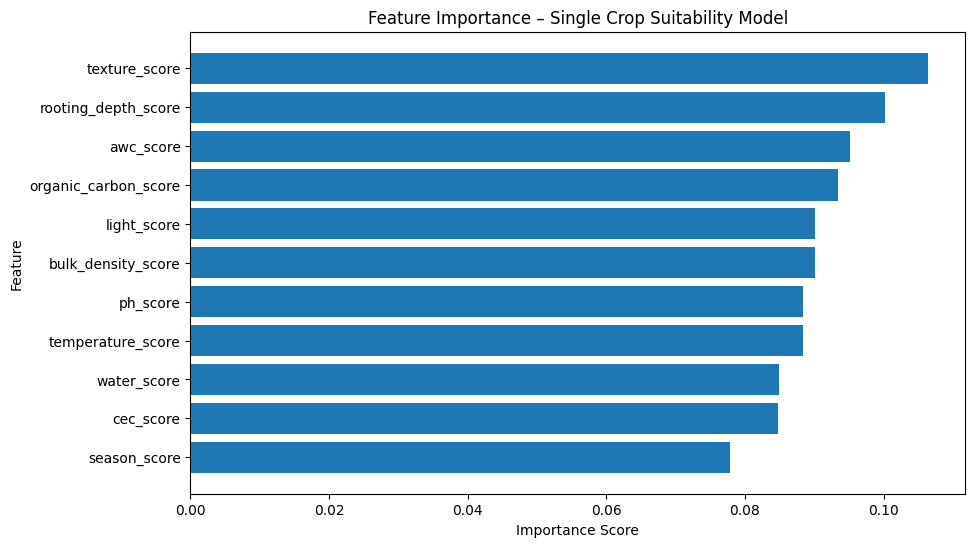

In [55]:
importances = model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_importance_df)


plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Feature Importance – Single Crop Suitability Model")
plt.gca().invert_yaxis()
plt.show()
